In [3441]:
#Student ID: 012082998

# import libraries
import pandas as pd
import numpy as np
!pip install missingno
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.stats import t 
from sklearn.decomposition import PCA
from scipy.stats.contingency import association

#import logit for Logistic Regression 
from statsmodels.formula.api import logit
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import confusion_matrix
from statsmodels.graphics.mosaicplot import mosaic

In [3166]:
#Importing Data and removing nulls and nans
filename = 'churn_clean.csv'
df = pd.read_csv(filename, na_values = ['null','N/A',' ', '', '.','nan']) 

In [3167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [3168]:
df.describe()


,CaseOrder,Zip,Lat,Lng,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,49153.319600,38.757567,-90.782536,9756.562400,2.0877,53.078400,39806.926771,10.001848,12.016000,0.994200,0.398000,34.526188,172.624816,3392.341550,3.490800,3.505100,3.487000,3.497500,3.492900,3.497300,3.509500,3.495600
std,2886.89568,27532.196108,5.437389,15.156142,14432.698671,2.1472,20.698882,28199.916702,2.976019,3.025898,0.988466,0.635953,26.443063,42.943094,2185.294852,1.037797,1.034641,1.027977,1.025816,1.024819,1.033586,1.028502,1.028633
min,1.00000,601.000000,17.966120,-171.688150,0.000000,0.0000,18.000000,348.670000,0.099747,1.000000,0.000000,0.000000,1.000259,79.978860,155.506715,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,26292.500000,35.341828,-97.082812,738.000000,0.0000,35.000000,19224.717500,8.018214,10.000000,0.000000,0.000000,7.917694,139.979239,1236.470827,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,5000.50000,48869.500000,39.395800,-87.918800,2910.500000,1.0000,53.000000,33170.605000,10.018560,12.000000,1.000000,0.000000,35.430507,167.484700,3279.536903,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
75%,7500.25000,71866.500000,42.106908,-80.088745,13168.000000,3.0000,71.000000,53246.170000,11.969485,14.000000,2.000000,1.000000,61.479795,200.734725,5586.141370,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,10000.00000,99929.000000,70.640660,-65.667850,111850.000000,10.0000,89.000000,258900.700000,21.207230,23.000000,7.000000,6.000000,71.999280,290.160419,7158.981530,7.000000,7.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000


In [3169]:
pd.set_option('display.max_columns', None)

print(df.head())

   CaseOrder Customer_id                           Interaction  \
0          1     K409198  aa90260b-4141-4a24-8e36-b04ce1f4f77b   
1          2     S120509  fb76459f-c047-4a9d-8af9-e0f7d4ac2524   
2          3     K191035  344d114c-3736-4be5-98f7-c72c281e2d35   
3          4      D90850  abfa2b40-2d43-4994-b15a-989b8c79e311   
4          5     K662701  68a861fd-0d20-4e51-a587-8a90407ee574   

                                UID         City State                 County  \
0  e885b299883d4f9fb18e39c75155d990  Point Baker    AK  Prince of Wales-Hyder   
1  f2de8bef964785f41a2959829830fb8a  West Branch    MI                 Ogemaw   
2  f1784cfa9f6d92ae816197eb175d3c71      Yamhill    OR                Yamhill   
3  dc8a365077241bb5cd5ccd305136b05e      Del Mar    CA              San Diego   
4  aabb64a116e83fdc4befc1fbab1663f9    Needville    TX              Fort Bend   

     Zip       Lat        Lng  Population      Area             TimeZone  \
0  99927  56.25100 -133.37571          3

In [3170]:
#Reducing Dataset to relevant columns for multiple Logistic Regression


df_model = df[
[
    'Churn',
    'Population',
    'Area',
    'Children',
    'Age',
    'Marital',
    'Outage_sec_perweek',
    'Yearly_equip_failure',
    'Techie',
    'Multiple',
    'Tenure',
    'MonthlyCharge',
    'Bandwidth_GB_Year',
    'Income',
    'Contract'
    
]]
    

In [3171]:
df_model.columns


Index(['Churn', 'Population', 'Area', 'Children', 'Age', 'Marital',
       'Outage_sec_perweek', 'Yearly_equip_failure', 'Techie', 'Multiple',
       'Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year', 'Income', 'Contract'],
      dtype='object')

In [3172]:
#Checking for missing values/nans

print(df_model.isna().sum())

Churn                   0
Population              0
Area                    0
Children                0
Age                     0
Marital                 0
Outage_sec_perweek      0
Yearly_equip_failure    0
Techie                  0
Multiple                0
Tenure                  0
MonthlyCharge           0
Bandwidth_GB_Year       0
Income                  0
Contract                0
dtype: int64


In [3173]:
print(df_model['Churn'].head())
print(df_model['Churn'].unique())

0     No
1    Yes
2     No
3     No
4    Yes
Name: Churn, dtype: object
['No' 'Yes']


In [3174]:
print(df_model.dtypes)

Churn                    object
Population                int64
Area                     object
Children                  int64
Age                       int64
Marital                  object
Outage_sec_perweek      float64
Yearly_equip_failure      int64
Techie                   object
Multiple                 object
Tenure                  float64
MonthlyCharge           float64
Bandwidth_GB_Year       float64
Income                  float64
Contract                 object
dtype: object


In [3175]:
print(df_model.head())

  Churn  Population      Area  Children  Age    Marital  Outage_sec_perweek  \
0    No          38     Urban         0   68    Widowed            7.978323   
1   Yes       10446     Urban         1   27    Married           11.699080   
2    No        3735     Urban         4   50    Widowed           10.752800   
3    No       13863  Suburban         1   48    Married           14.913540   
4   Yes       11352  Suburban         0   83  Separated            8.147417   

   Yearly_equip_failure Techie Multiple     Tenure  MonthlyCharge  \
0                     1     No       No   6.795513     172.455519   
1                     1    Yes      Yes   1.156681     242.632554   
2                     1    Yes      Yes  15.754144     159.947583   
3                     0    Yes       No  17.087227     119.956840   
4                     1     No       No   1.670972     149.948316   

   Bandwidth_GB_Year    Income        Contract  
0         904.536110  28561.99        One year  
1         80

In [3176]:
#convert categorical columns into the correct datatype

cat_cols = ['Area',
        'Marital',
        'Techie',
        'Multiple',
        'Contract']

for col in cat_cols:

    df_model[col] = df_model[col].astype('category')

C:\Users\nam\AppData\Local\Temp\ipykernel_70768\3038000412.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = df_model[col].astype('category')
C:\Users\nam\AppData\Local\Temp\ipykernel_70768\3038000412.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = df_model[col].astype('category')
C:\Users\nam\AppData\Local\Temp\ipykernel_70768\3038000412.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

In [3177]:
print(df_model.dtypes)

Churn                     object
Population                 int64
Area                    category
Children                   int64
Age                        int64
Marital                 category
Outage_sec_perweek       float64
Yearly_equip_failure       int64
Techie                  category
Multiple                category
Tenure                   float64
MonthlyCharge            float64
Bandwidth_GB_Year        float64
Income                   float64
Contract                category
dtype: object


In [3178]:
print(df_model.head())

  Churn  Population      Area  Children  Age    Marital  Outage_sec_perweek  \
0    No          38     Urban         0   68    Widowed            7.978323   
1   Yes       10446     Urban         1   27    Married           11.699080   
2    No        3735     Urban         4   50    Widowed           10.752800   
3    No       13863  Suburban         1   48    Married           14.913540   
4   Yes       11352  Suburban         0   83  Separated            8.147417   

   Yearly_equip_failure Techie Multiple     Tenure  MonthlyCharge  \
0                     1     No       No   6.795513     172.455519   
1                     1    Yes      Yes   1.156681     242.632554   
2                     1    Yes      Yes  15.754144     159.947583   
3                     0    Yes       No  17.087227     119.956840   
4                     1     No       No   1.670972     149.948316   

   Bandwidth_GB_Year    Income        Contract  
0         904.536110  28561.99        One year  
1         80

In [3179]:
#Turn binary categoricals into Yes/No for easier model interpretation

df_model['Churn'] = df_model['Churn'].replace({'Yes':1,'No':0})
df_model['Techie'] = df_model['Techie'].replace({'Yes':1,'No':0})
df_model['Multiple'] = df_model['Multiple'].replace({'Yes':1,'No':0})


C:\Users\nam\AppData\Local\Temp\ipykernel_70768\3656361071.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model['Churn'] = df_model['Churn'].replace({'Yes':1,'No':0})
C:\Users\nam\AppData\Local\Temp\ipykernel_70768\3656361071.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['Churn'] = df_model['Churn'].replace({'Yes':1,'No':0})
C:\Users\nam\AppData\Local\Temp\ipykernel_70768\3656361071.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To re

In [3180]:
#Checking to see if both column have been correctly transformed to 0/1 for better interpretation of the Logistic regression model


print(df_model[['Techie','Churn','Multiple']].head())

print(df_model['Techie'].unique())

print(df_model['Churn'].unique())

print(df_model['Multiple'].unique())

  Techie  Churn Multiple
0      0      0        0
1      1      1        1
2      1      0        1
3      1      0        0
4      0      1        0
[0, 1]
Categories (2, int64): [0, 1]
[0 1]
[0, 1]
Categories (2, int64): [0, 1]


In [3181]:
print(df_model.head())

   Churn  Population      Area  Children  Age    Marital  Outage_sec_perweek  \
0      0          38     Urban         0   68    Widowed            7.978323   
1      1       10446     Urban         1   27    Married           11.699080   
2      0        3735     Urban         4   50    Widowed           10.752800   
3      0       13863  Suburban         1   48    Married           14.913540   
4      1       11352  Suburban         0   83  Separated            8.147417   

   Yearly_equip_failure Techie Multiple     Tenure  MonthlyCharge  \
0                     1      0        0   6.795513     172.455519   
1                     1      1        1   1.156681     242.632554   
2                     1      1        1  15.754144     159.947583   
3                     0      1        0  17.087227     119.956840   
4                     1      0        0   1.670972     149.948316   

   Bandwidth_GB_Year    Income        Contract  
0         904.536110  28561.99        One year  
1     

In [3182]:
print(df_model['Area'].unique())

print(df_model['Marital'].unique())

print(df_model['Multiple'].unique())

print(df_model['Contract'].unique())

['Urban', 'Suburban', 'Rural']
Categories (3, object): ['Rural', 'Suburban', 'Urban']
['Widowed', 'Married', 'Separated', 'Never Married', 'Divorced']
Categories (5, object): ['Divorced', 'Married', 'Never Married', 'Separated', 'Widowed']
[0, 1]
Categories (2, int64): [0, 1]
['One year', 'Month-to-month', 'Two Year']
Categories (3, object): ['Month-to-month', 'One year', 'Two Year']


In [3183]:
print(df_model.dtypes)

Churn                      int64
Population                 int64
Area                    category
Children                   int64
Age                        int64
Marital                 category
Outage_sec_perweek       float64
Yearly_equip_failure       int64
Techie                  category
Multiple                category
Tenure                   float64
MonthlyCharge            float64
Bandwidth_GB_Year        float64
Income                   float64
Contract                category
dtype: object


In [3184]:
print(df_model.head())

   Churn  Population      Area  Children  Age    Marital  Outage_sec_perweek  \
0      0          38     Urban         0   68    Widowed            7.978323   
1      1       10446     Urban         1   27    Married           11.699080   
2      0        3735     Urban         4   50    Widowed           10.752800   
3      0       13863  Suburban         1   48    Married           14.913540   
4      1       11352  Suburban         0   83  Separated            8.147417   

   Yearly_equip_failure Techie Multiple     Tenure  MonthlyCharge  \
0                     1      0        0   6.795513     172.455519   
1                     1      1        1   1.156681     242.632554   
2                     1      1        1  15.754144     159.947583   
3                     0      1        0  17.087227     119.956840   
4                     1      0        0   1.670972     149.948316   

   Bandwidth_GB_Year    Income        Contract  
0         904.536110  28561.99        One year  
1     

In [3185]:
#Turn back categorical binaries into Integer for better model interpretation
    
df_model['Techie'] = df_model['Techie'].astype(int)
df_model['Multiple'] = df_model['Multiple'].astype(int)

C:\Users\nam\AppData\Local\Temp\ipykernel_70768\1876604703.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['Techie'] = df_model['Techie'].astype(int)
C:\Users\nam\AppData\Local\Temp\ipykernel_70768\1876604703.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['Multiple'] = df_model['Multiple'].astype(int)


In [3186]:
#Confirmation of Data types


print(df_model['Techie'].dtype)
print(df_model['Multiple'].dtype)



int32
int32


In [3187]:
print(df_model.head(5))


   Churn  Population      Area  Children  Age    Marital  Outage_sec_perweek  \
0      0          38     Urban         0   68    Widowed            7.978323   
1      1       10446     Urban         1   27    Married           11.699080   
2      0        3735     Urban         4   50    Widowed           10.752800   
3      0       13863  Suburban         1   48    Married           14.913540   
4      1       11352  Suburban         0   83  Separated            8.147417   

   Yearly_equip_failure  Techie  Multiple     Tenure  MonthlyCharge  \
0                     1       0         0   6.795513     172.455519   
1                     1       1         1   1.156681     242.632554   
2                     1       1         1  15.754144     159.947583   
3                     0       1         0  17.087227     119.956840   
4                     1       0         0   1.670972     149.948316   

   Bandwidth_GB_Year    Income        Contract  
0         904.536110  28561.99        One y

In [3188]:
#Double Checking Dtypes

print(df_model.dtypes)

Churn                      int64
Population                 int64
Area                    category
Children                   int64
Age                        int64
Marital                 category
Outage_sec_perweek       float64
Yearly_equip_failure       int64
Techie                     int32
Multiple                   int32
Tenure                   float64
MonthlyCharge            float64
Bandwidth_GB_Year        float64
Income                   float64
Contract                category
dtype: object


In [3189]:
#Double checking missing values 

df_model.isnull().sum()

Churn                   0
Population              0
Area                    0
Children                0
Age                     0
Marital                 0
Outage_sec_perweek      0
Yearly_equip_failure    0
Techie                  0
Multiple                0
Tenure                  0
MonthlyCharge           0
Bandwidth_GB_Year       0
Income                  0
Contract                0
dtype: int64

<Axes: xlabel='Population'>

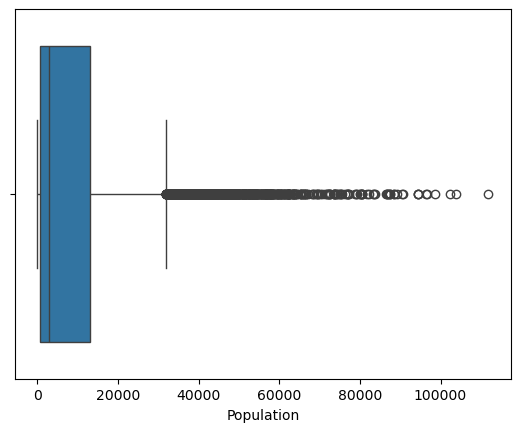

In [3190]:
sns.boxplot(x='Population', data=df_model)

<Axes: xlabel='Children'>

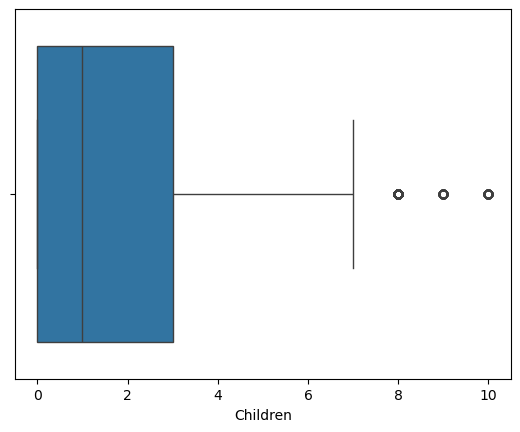

In [3191]:
sns.boxplot(x='Children',data=df_model)

In [3192]:
print((df['Children']>7).sum())

401


<Axes: xlabel='Age'>

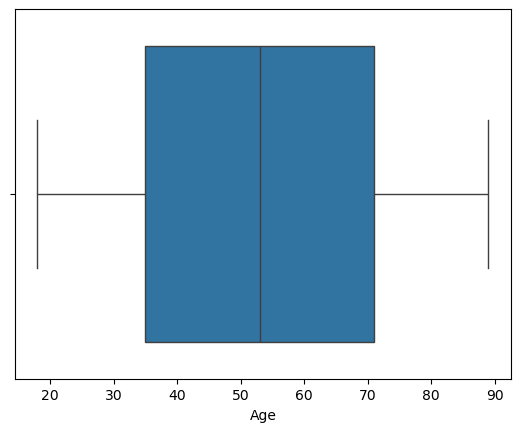

In [3193]:
sns.boxplot(x='Age',data=df_model)

<Axes: xlabel='Outage_sec_perweek'>

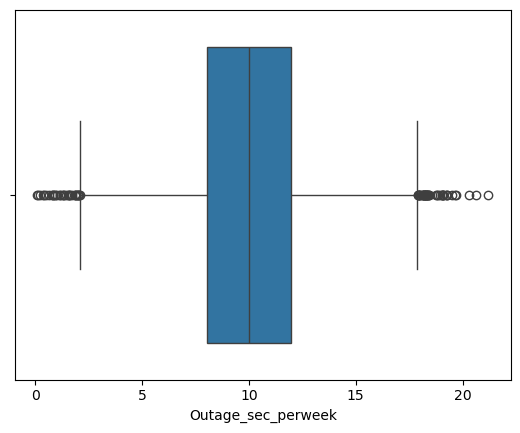

In [3194]:
sns.boxplot(x='Outage_sec_perweek', data=df_model)

<Axes: xlabel='Yearly_equip_failure'>

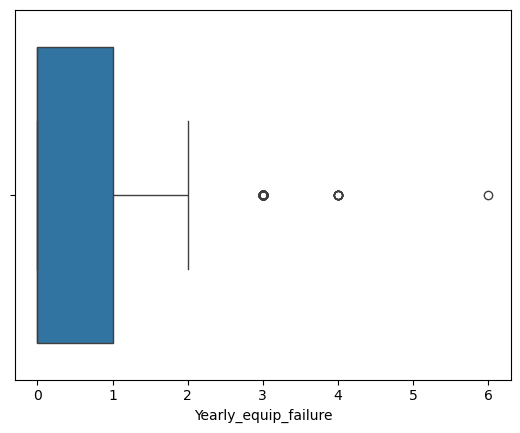

In [3195]:
sns.boxplot(x='Yearly_equip_failure',data=df_model)

In [3196]:
print((df_model['Yearly_equip_failure']> 2).sum()) 


94


<Axes: xlabel='Tenure'>

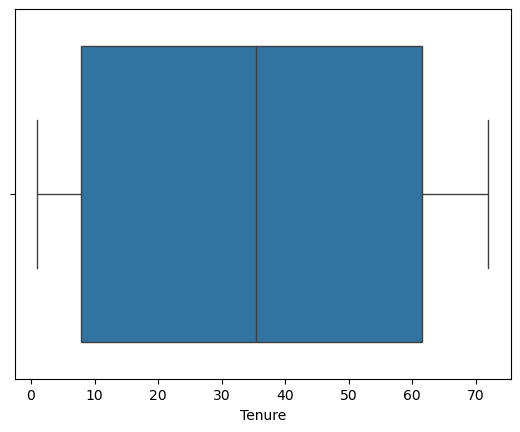

In [3197]:
sns.boxplot(x='Tenure',data=df_model)

<Axes: xlabel='MonthlyCharge'>

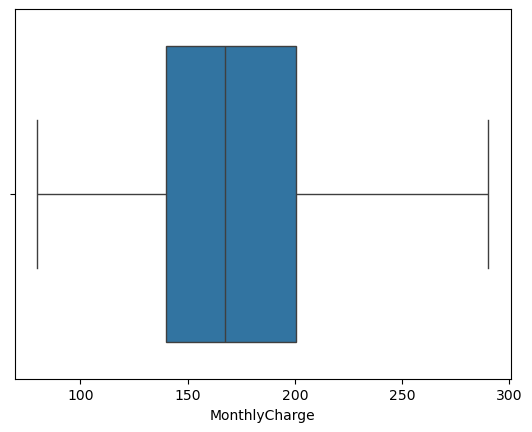

In [3198]:
sns.boxplot(x='MonthlyCharge',data=df_model)

C:\Users\nam\anaconda3\Lib\site-packages\IPython\core\displayhook.py:281: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


<Axes: xlabel='Bandwidth_GB_Year'>

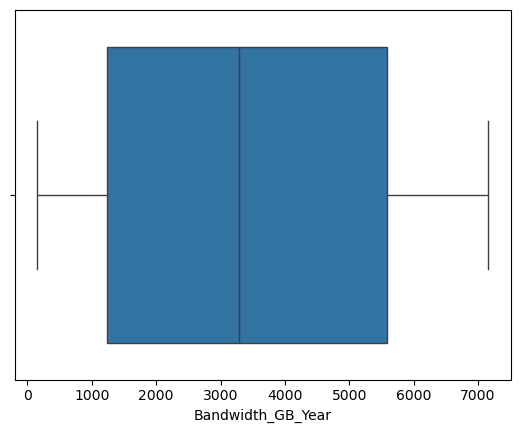

In [3199]:
sns.boxplot(x= 'Bandwidth_GB_Year',data=df_model)

<Axes: xlabel='Income'>

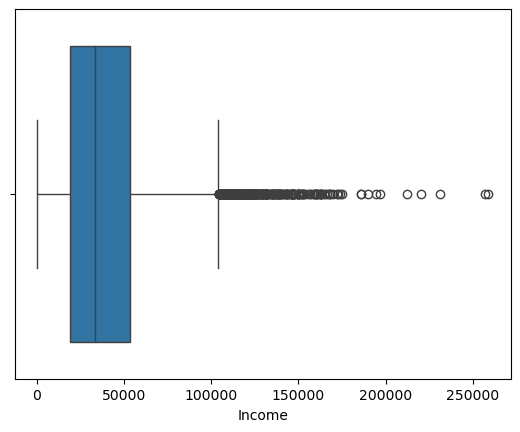

In [3200]:
sns.boxplot(x='Income',data=df_model)

In [3201]:
#Capping max values at 175k 

df_model.loc[df_model['Income'] > 175000, 'Income'] = 175000


C2.
Describe the dependent variable and all independent variables using summary statistics that are required to answer the research question, including a screenshot of the summary statistics output for each of these variables.

Churn                   
Population             0
Area                   0
Children               0
Age                    0
Marital                0
Outage_sec_perweek     0
Yearly_equip_failre    0
Techie                 0
Multiple               0
Tenure                 0
MonthlyCharge          0
Bandwidth_GBYear       0
Income                 0

In [3204]:
#Printing summary for Churn

print(df_model['Churn'].value_counts())
print(df_model['Churn'].value_counts(normalize=True) * 100)

Churn
0    7350
1    2650
Name: count, dtype: int64
Churn
0    73.5
1    26.5
Name: proportion, dtype: float64


In [3205]:
#Printing summary statistics of Population

print(df_model['Population'].describe())

print('Range:',df_model['Population'].max() - df_model['Population'].min())

count     10000.000000
mean       9756.562400
std       14432.698671
min           0.000000
25%         738.000000
50%        2910.500000
75%       13168.000000
max      111850.000000
Name: Population, dtype: float64
Range: 111850


In [3206]:
#Printing summary for Area

print(df_model['Area'].value_counts())
print(df_model['Area'].value_counts(normalize=True) * 100)

Area
Suburban    3346
Rural       3327
Urban       3327
Name: count, dtype: int64
Area
Suburban    33.46
Rural       33.27
Urban       33.27
Name: proportion, dtype: float64


In [3207]:
#Printing summary statistics of Children

print(df_model['Children'].describe())

print('Range:',df_model['Children'].max() - df_model['Children'].min())

count    10000.0000
mean         2.0877
std          2.1472
min          0.0000
25%          0.0000
50%          1.0000
75%          3.0000
max         10.0000
Name: Children, dtype: float64
Range: 10


In [3208]:
#Printing summary statistics of Age

print(df_model['Age'].describe())

print('Range:',df_model['Age'].max() - df_model['Age'].min())

count    10000.000000
mean        53.078400
std         20.698882
min         18.000000
25%         35.000000
50%         53.000000
75%         71.000000
max         89.000000
Name: Age, dtype: float64
Range: 71


In [3209]:
#Printing summary for Marital

print(df_model['Marital'].value_counts())
print(df_model['Marital'].value_counts(normalize=True) * 100)

Marital
Divorced         2092
Widowed          2027
Separated        2014
Never Married    1956
Married          1911
Name: count, dtype: int64
Marital
Divorced         20.92
Widowed          20.27
Separated        20.14
Never Married    19.56
Married          19.11
Name: proportion, dtype: float64


In [3210]:
#Printing summary statistics of Outage_sec_perweek

print(df_model['Outage_sec_perweek'].describe())

print('Range:',df_model['Outage_sec_perweek'].max() - df_model['Outage_sec_perweek'].min())

count    10000.000000
mean        10.001848
std          2.976019
min          0.099747
25%          8.018214
50%         10.018560
75%         11.969485
max         21.207230
Name: Outage_sec_perweek, dtype: float64
Range: 21.10748306


In [3211]:
#Printing summary statistics of Yearly_equip_failure

print(df_model['Yearly_equip_failure'].describe())

print('Range:',df_model['Yearly_equip_failure'].max() - df_model['Yearly_equip_failure'].min())

count    10000.000000
mean         0.398000
std          0.635953
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          6.000000
Name: Yearly_equip_failure, dtype: float64
Range: 6


In [3212]:
#Printing summary for Techie

print(df_model['Techie'].value_counts())
print(df_model['Techie'].value_counts(normalize=True) * 100)

Techie
0    8321
1    1679
Name: count, dtype: int64
Techie
0    83.21
1    16.79
Name: proportion, dtype: float64


In [3213]:
#Printing summary for Multiple

print(df_model['Multiple'].value_counts())
print(df_model['Multiple'].value_counts(normalize=True) * 100)

Multiple
0    5392
1    4608
Name: count, dtype: int64
Multiple
0    53.92
1    46.08
Name: proportion, dtype: float64


In [3214]:
#Printing summary statistics of Tenure

print(df_model['Tenure'].describe())

print('Range:',df_model['Tenure'].max() - df_model['Tenure'].min())

count    10000.000000
mean        34.526188
std         26.443063
min          1.000259
25%          7.917694
50%         35.430507
75%         61.479795
max         71.999280
Name: Tenure, dtype: float64
Range: 70.99902066


In [3215]:
#Printing summary statistics of MonthlyCharge

print(df_model['MonthlyCharge'].describe())

print('Range:',df_model['MonthlyCharge'].max() - df_model['MonthlyCharge'].min())

count    10000.000000
mean       172.624816
std         42.943094
min         79.978860
25%        139.979239
50%        167.484700
75%        200.734725
max        290.160419
Name: MonthlyCharge, dtype: float64
Range: 210.181559


In [3216]:
#Printing summary statistics of Bandwidth_GB_Year

print(df_model['Bandwidth_GB_Year'].describe())

print('Range:',df_model['Bandwidth_GB_Year'].max() - df_model['Bandwidth_GB_Year'].min())

count    10000.000000
mean      3392.341550
std       2185.294852
min        155.506715
25%       1236.470827
50%       3279.536903
75%       5586.141370
max       7158.981530
Name: Bandwidth_GB_Year, dtype: float64
Range: 7003.4748152


In [3217]:
#Printing summary statistics of Income

print(df_model['Income'].describe())

print('Range:',df_model['Income'].max() - df_model['Income'].min())

count     10000.000000
mean      39768.591427
std       27976.727587
min         348.670000
25%       19224.717500
50%       33170.605000
75%       53246.170000
max      175000.000000
Name: Income, dtype: float64
Range: 174651.33


In [3218]:
#Printing summary for Contract

print(df_model['Contract'].value_counts())
print(df_model['Contract'].value_counts(normalize=True) * 100)

Contract
Month-to-month    5456
Two Year          2442
One year          2102
Name: count, dtype: int64
Contract
Month-to-month    54.56
Two Year          24.42
One year          21.02
Name: proportion, dtype: float64


In [3219]:
print(df_model.dtypes)

Churn                      int64
Population                 int64
Area                    category
Children                   int64
Age                        int64
Marital                 category
Outage_sec_perweek       float64
Yearly_equip_failure       int64
Techie                     int32
Multiple                   int32
Tenure                   float64
MonthlyCharge            float64
Bandwidth_GB_Year        float64
Income                   float64
Contract                category
dtype: object


In [3220]:
pd.set_option('display.max_columns', None)

print(df_model.head())

print(df_model[['Area','Marital','Techie','Multiple']].nunique())
print(df_model['Marital'].unique())

   Churn  Population      Area  Children  Age    Marital  Outage_sec_perweek  \
0      0          38     Urban         0   68    Widowed            7.978323   
1      1       10446     Urban         1   27    Married           11.699080   
2      0        3735     Urban         4   50    Widowed           10.752800   
3      0       13863  Suburban         1   48    Married           14.913540   
4      1       11352  Suburban         0   83  Separated            8.147417   

   Yearly_equip_failure  Techie  Multiple     Tenure  MonthlyCharge  \
0                     1       0         0   6.795513     172.455519   
1                     1       1         1   1.156681     242.632554   
2                     1       1         1  15.754144     159.947583   
3                     0       1         0  17.087227     119.956840   
4                     1       0         0   1.670972     149.948316   

   Bandwidth_GB_Year    Income        Contract  
0         904.536110  28561.99        One y

3.  Generate univariate and bivariate visualizations of the distributions of the dependent and independent variables, including the dependent variable in your bivariate visualizations.

Univariate:

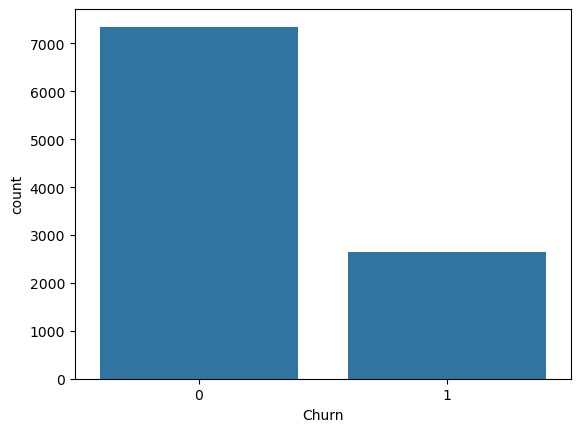

In [3223]:
sns.countplot(x='Churn', data=df_model)
plt.show()

<Axes: xlabel='Population', ylabel='Count'>

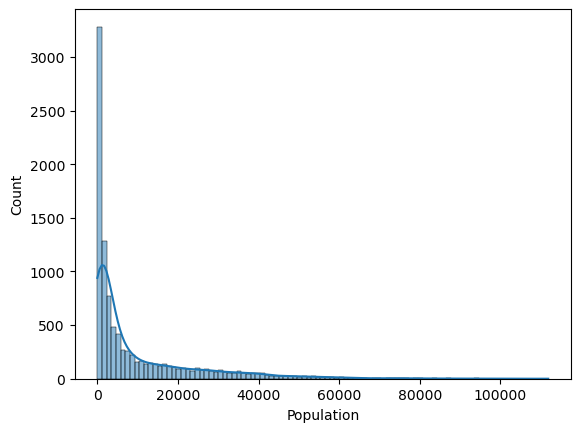

In [3224]:
sns.histplot(df_model['Population'], kde=True)

<Axes: xlabel='Area', ylabel='count'>

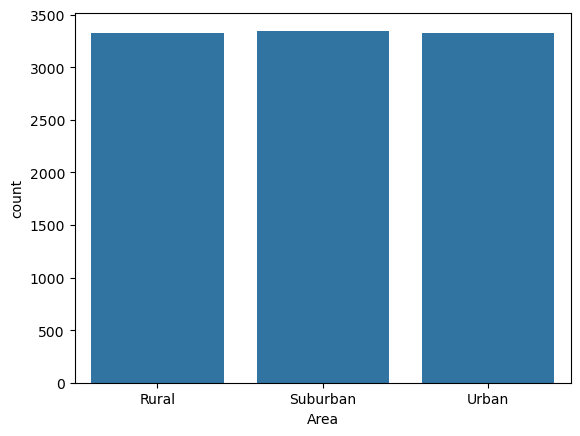

In [3225]:
sns.countplot(x='Area', data=df_model)


<Axes: xlabel='Children', ylabel='Count'>

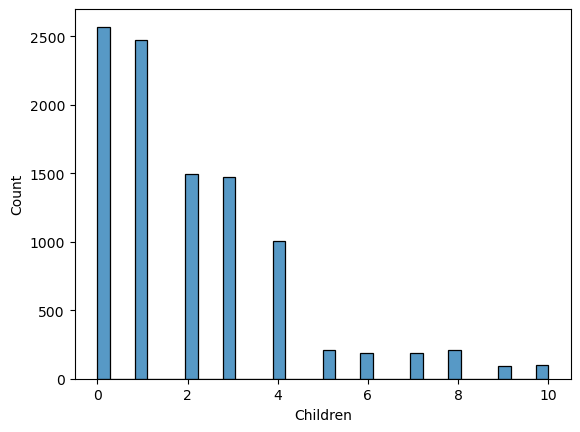

In [3226]:
sns.histplot(x='Children', data=df_model)


<Axes: xlabel='Age', ylabel='Count'>

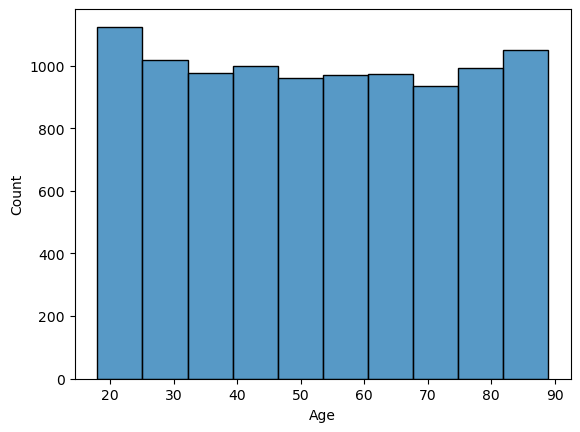

In [3227]:
sns.histplot(x='Age',data=df_model,bins = 10)

<Axes: xlabel='Marital', ylabel='count'>

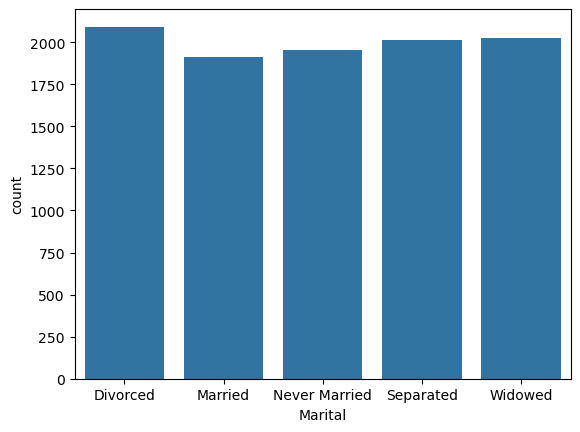

In [3228]:

sns.countplot(x='Marital',data=df_model)

<Axes: xlabel='Outage_sec_perweek', ylabel='Count'>

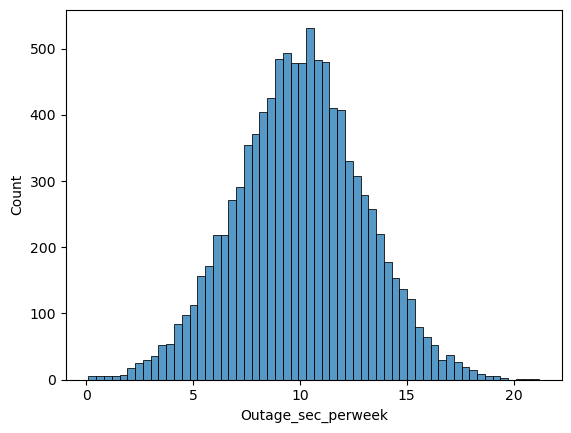

In [3229]:

sns.histplot(x='Outage_sec_perweek',data=df_model)

<Axes: xlabel='Yearly_equip_failure', ylabel='count'>

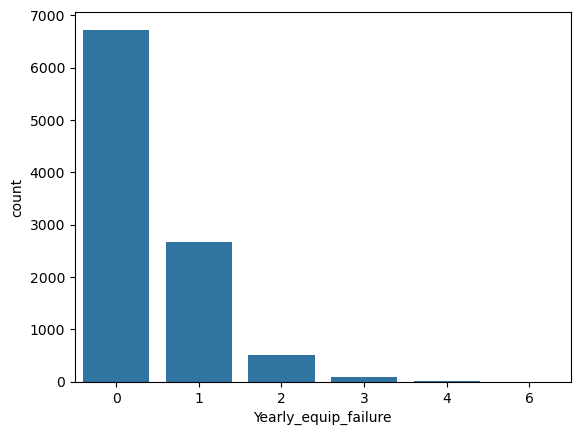

In [3230]:
sns.countplot(x='Yearly_equip_failure',data=df_model)


<Axes: xlabel='Techie', ylabel='count'>

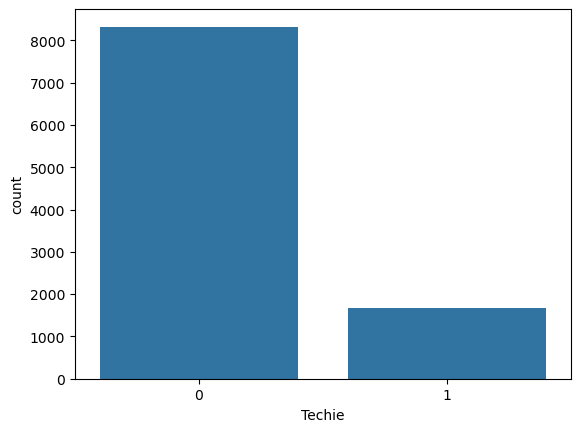

In [3231]:
sns.countplot(x='Techie',data=df_model)

<Axes: xlabel='MonthlyCharge', ylabel='Count'>

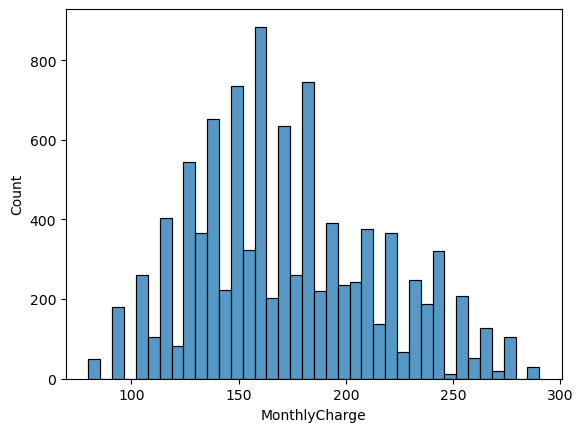

In [3232]:
sns.histplot(x='MonthlyCharge',data=df_model)

<Axes: xlabel='Bandwidth_GB_Year', ylabel='Count'>

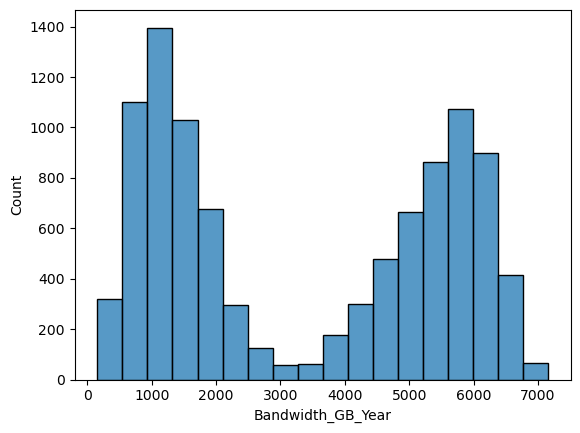

In [3233]:
sns.histplot(x='Bandwidth_GB_Year',data=df_model)

<Axes: xlabel='Income', ylabel='Count'>

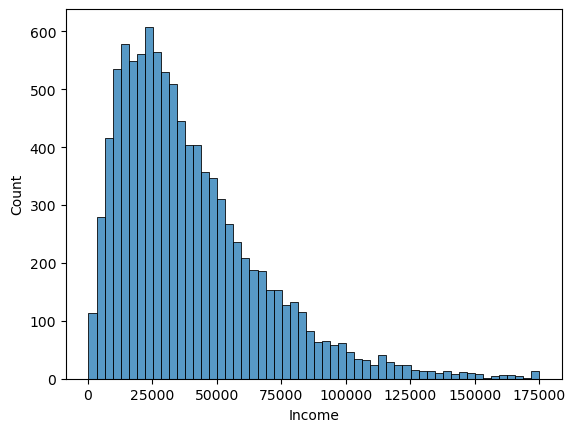

In [3234]:
sns.histplot(x='Income',data=df_model)

<Axes: xlabel='Contract', ylabel='count'>

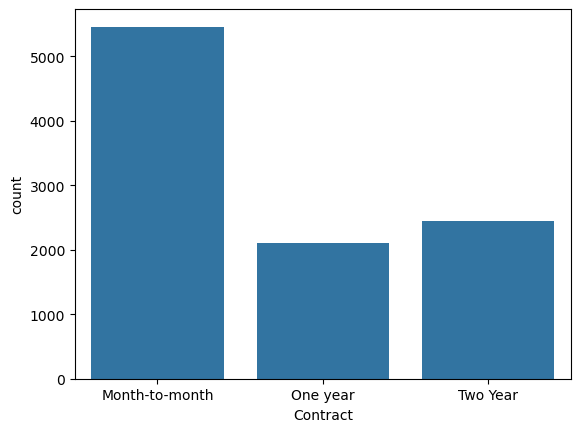

In [3235]:
sns.countplot(x='Contract',data=df_model)

Bivariate visualizations
Dependent variable: Churn


<Axes: xlabel='Churn', ylabel='Population'>

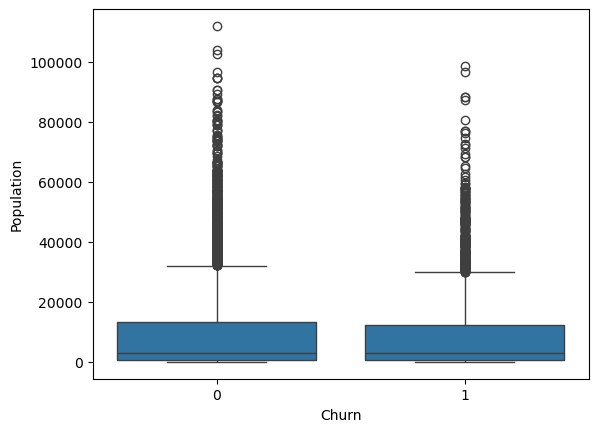

In [3237]:
#Churn X Population Bivariate

sns.boxplot(x='Churn',y='Population',data=df_model)

<Axes: xlabel='Area', ylabel='count'>

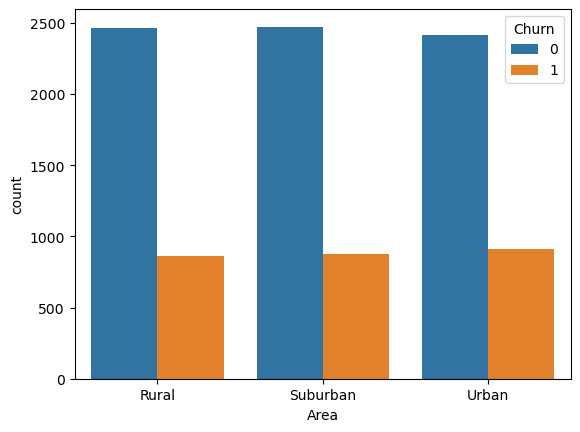

In [3238]:
#Churn X Area
sns.countplot(x='Area', hue='Churn', data=df_model)


<Axes: xlabel='Churn', ylabel='Children'>

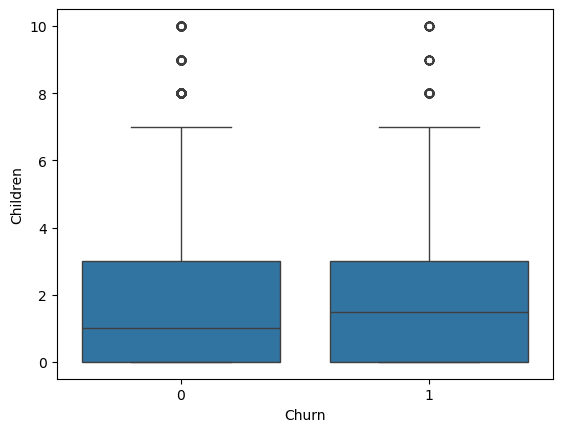

In [3239]:
#Churn x Children

sns.boxplot(x='Churn',y='Children',data=df_model)

<Axes: xlabel='Churn', ylabel='Age'>

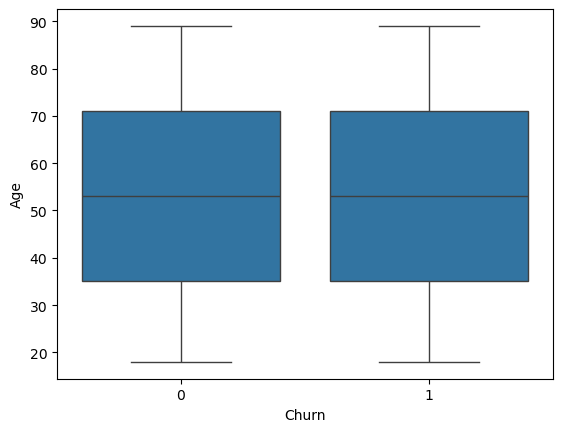

In [3240]:
#Churn X Age

sns.boxplot(x='Churn',y='Age',data=df_model)

<Axes: xlabel='Marital', ylabel='count'>

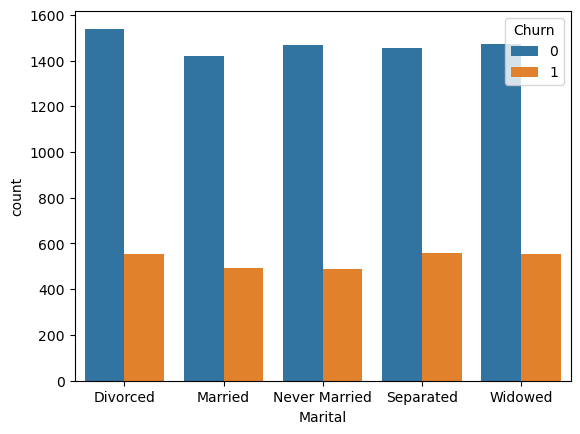

In [3241]:
#Churn X Marital

sns.countplot(x='Marital',hue = 'Churn',data=df_model)

<Axes: xlabel='Churn', ylabel='Outage_sec_perweek'>

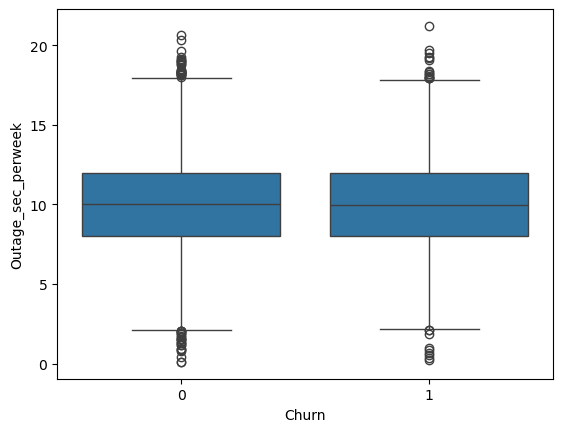

In [3242]:
#Churn X Outage_sec_perweek
sns.boxplot(x='Churn',y='Outage_sec_perweek',data=df_model)

<Axes: xlabel='Churn', ylabel='Yearly_equip_failure'>

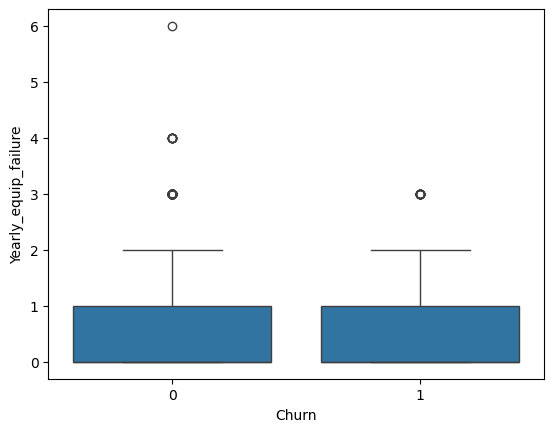

In [3243]:
#Churn x Yearly_equip_failure

sns.boxplot(x='Churn',y='Yearly_equip_failure',data=df_model)

<Axes: xlabel='Techie', ylabel='count'>

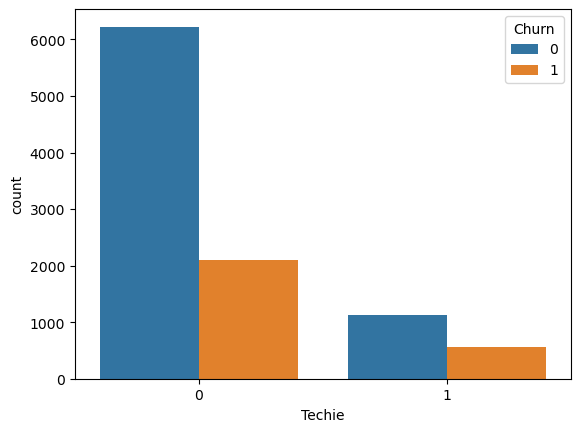

In [3244]:
#Churn X Techie

sns.countplot(x='Techie',hue = 'Churn',data=df_model)

<Axes: xlabel='Multiple', ylabel='count'>

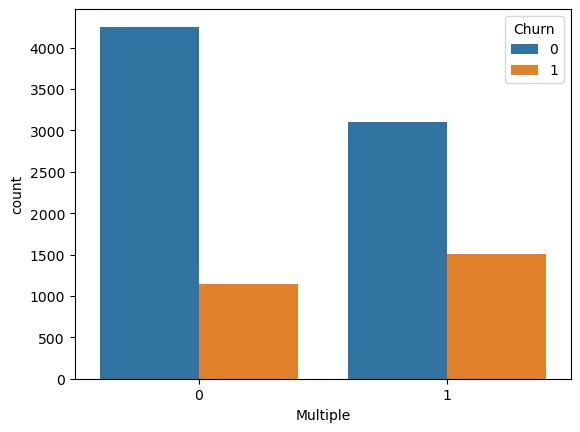

In [3245]:
#Churn X Multiple

sns.countplot(x='Multiple',hue = 'Churn',data=df_model)

<Axes: xlabel='Churn', ylabel='Tenure'>

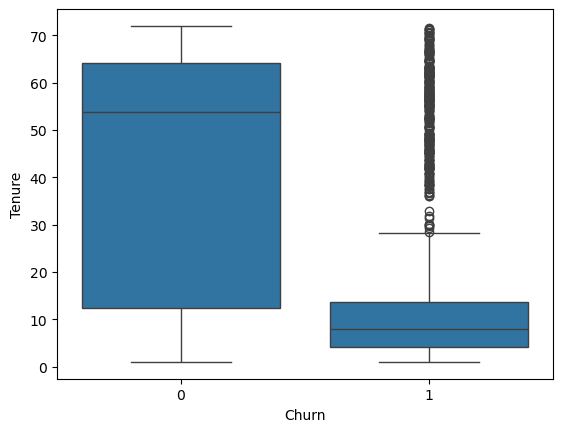

In [3246]:
#Churn X Tenure

sns.boxplot(x='Churn',y='Tenure',data=df_model)

<Axes: xlabel='Churn', ylabel='MonthlyCharge'>

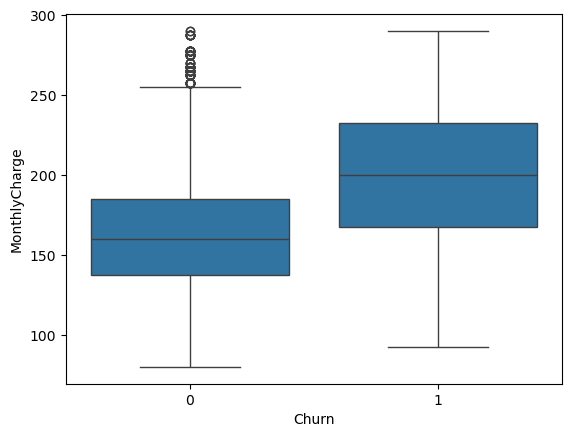

In [3247]:
#Churn x Monthlycharge

sns.boxplot(x='Churn',y='MonthlyCharge',data=df_model)

<Axes: xlabel='Churn', ylabel='Bandwidth_GB_Year'>

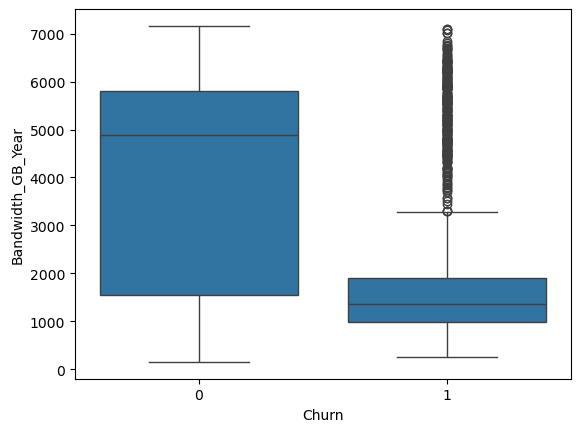

In [3248]:
#Churn X Bandwidth_GB_Year

sns.boxplot(x='Churn',y='Bandwidth_GB_Year',data=df_model)

<Axes: xlabel='Churn', ylabel='Income'>

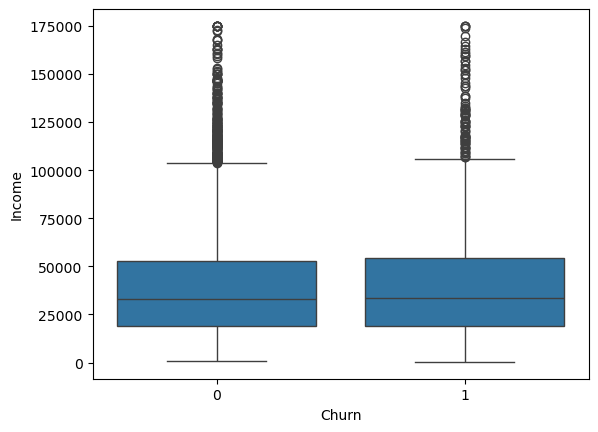

In [3249]:
#Churn X Income

sns.boxplot(x='Churn',y='Income',data=df_model)

<Axes: xlabel='Contract', ylabel='count'>

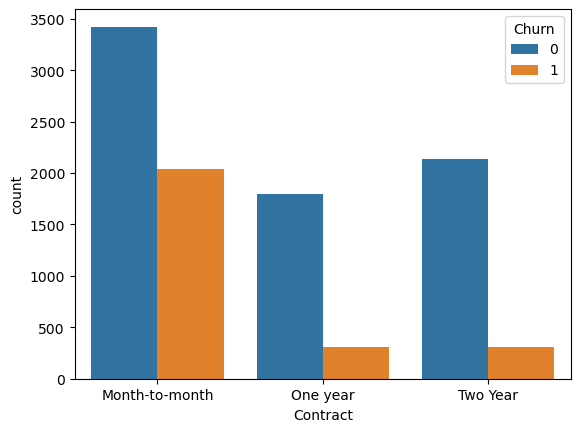

In [3250]:
#Churn X Contract

sns.countplot(x='Contract',hue = 'Churn',data=df_model)

In [3251]:

print(df_model.dtypes)

Churn                      int64
Population                 int64
Area                    category
Children                   int64
Age                        int64
Marital                 category
Outage_sec_perweek       float64
Yearly_equip_failure       int64
Techie                     int32
Multiple                   int32
Tenure                   float64
MonthlyCharge            float64
Bandwidth_GB_Year        float64
Income                   float64
Contract                category
dtype: object


In [3252]:
print(df_model.head(10))

   Churn  Population      Area  Children  Age        Marital  \
0      0          38     Urban         0   68        Widowed   
1      1       10446     Urban         1   27        Married   
2      0        3735     Urban         4   50        Widowed   
3      0       13863  Suburban         1   48        Married   
4      1       11352  Suburban         0   83      Separated   
5      0       17701     Urban         3   83  Never Married   
6      1        2535  Suburban         0   79        Widowed   
7      1       23144  Suburban         2   30        Married   
8      0       17351  Suburban         2   49      Separated   
9      0       20193     Rural         1   86        Married   

   Outage_sec_perweek  Yearly_equip_failure  Techie  Multiple     Tenure  \
0            7.978323                     1       0         0   6.795513   
1           11.699080                     1       1         1   1.156681   
2           10.752800                     1       1         1  15.7

One hot encode list:
Area, Marital, Contract

In [3254]:
#One hot encode categorical nominal categories

one_hot_category= ['Marital','Area','Contract']

df_model=pd.get_dummies(df_model,
                        columns=one_hot_category,
                        drop_first=True
                       )


In [3255]:

#Check VIC
X_init = df_model.drop(columns='Churn').astype(float)

vif_score = pd.DataFrame()
vif_score['Features'] = X_init.columns
vif_score['VIF']=[variance_inflation_factor(X_init.values,i) for i in range(X_init.shape[1])]
vif_score['VIF']= round(vif_score['VIF'],2)
vif_score=vif_score.sort_values(by="VIF",ascending=False)
vif_score

,Features,VIF
9,Bandwidth_GB_Year,313.08
7,Tenure,247.76
8,MonthlyCharge,21.82
3,Outage_sec_perweek,9.46
2,Age,7.13
10,Income,2.89
6,Multiple,2.18
1,Children,2.08
15,Area_Suburban,1.95
16,Area_Urban,1.94


In [3256]:
print(df_model.columns)

Index(['Churn', 'Population', 'Children', 'Age', 'Outage_sec_perweek',
       'Yearly_equip_failure', 'Techie', 'Multiple', 'Tenure', 'MonthlyCharge',
       'Bandwidth_GB_Year', 'Income', 'Marital_Married',
       'Marital_Never Married', 'Marital_Separated', 'Marital_Widowed',
       'Area_Suburban', 'Area_Urban', 'Contract_One year',
       'Contract_Two Year'],
      dtype='object')


In [3257]:
print(df_model.head(5))

   Churn  Population  Children  Age  Outage_sec_perweek  Yearly_equip_failure  \
0      0          38         0   68            7.978323                     1   
1      1       10446         1   27           11.699080                     1   
2      0        3735         4   50           10.752800                     1   
3      0       13863         1   48           14.913540                     0   
4      1       11352         0   83            8.147417                     1   

   Techie  Multiple     Tenure  MonthlyCharge  Bandwidth_GB_Year    Income  \
0       0         0   6.795513     172.455519         904.536110  28561.99   
1       1         1   1.156681     242.632554         800.982766  21704.77   
2       1         1  15.754144     159.947583        2054.706961   9609.57   
3       1         0  17.087227     119.956840        2164.579412  18925.23   
4       0         0   1.670972     149.948316         271.493436  40074.19   

   Marital_Married  Marital_Never Married  M

In [3258]:
#Rename columns, replace empty spaces at InternetService_fiber optic with no empty space in between

df_model.columns = (
    df_model.columns
    .str.replace(' ', '_')
)

In [3259]:
print(df_model.columns)

Index(['Churn', 'Population', 'Children', 'Age', 'Outage_sec_perweek',
       'Yearly_equip_failure', 'Techie', 'Multiple', 'Tenure', 'MonthlyCharge',
       'Bandwidth_GB_Year', 'Income', 'Marital_Married',
       'Marital_Never_Married', 'Marital_Separated', 'Marital_Widowed',
       'Area_Suburban', 'Area_Urban', 'Contract_One_year',
       'Contract_Two_Year'],
      dtype='object')


In [3260]:
#Saving prepared dataset for Logistic regression as CSV

df_model.to_csv('C5_prepared_Dataset_Logistic.csv', index=False)


In [3261]:

print(df_model.columns)

Index(['Churn', 'Population', 'Children', 'Age', 'Outage_sec_perweek',
       'Yearly_equip_failure', 'Techie', 'Multiple', 'Tenure', 'MonthlyCharge',
       'Bandwidth_GB_Year', 'Income', 'Marital_Married',
       'Marital_Never_Married', 'Marital_Separated', 'Marital_Widowed',
       'Area_Suburban', 'Area_Urban', 'Contract_One_year',
       'Contract_Two_Year'],
      dtype='object')


C2:

1.  Construct an initial logistic regression model from all independent variables that were identified in part C2.

In [3263]:
#Creating initial logistic regression model


model1= logit("Churn ~ Population + Children + Age + Outage_sec_perweek + Yearly_equip_failure + Techie + Multiple + Tenure + MonthlyCharge"
              "+ Bandwidth_GB_Year + Income + Marital_Married + Marital_Never_Married + Marital_Separated + Marital_Widowed + Area_Suburban"
              "+ Area_Urban + Contract_One_year + Contract_Two_Year" ,data=df_model).fit()



              

Optimization terminated successfully.
         Current function value: 0.235331
         Iterations 9


In [3264]:
#Confusion Matrix for model1

conf_matrix_1 = model1.pred_table()
print(conf_matrix_1)

[[6885.  465.]
 [ 565. 2085.]]


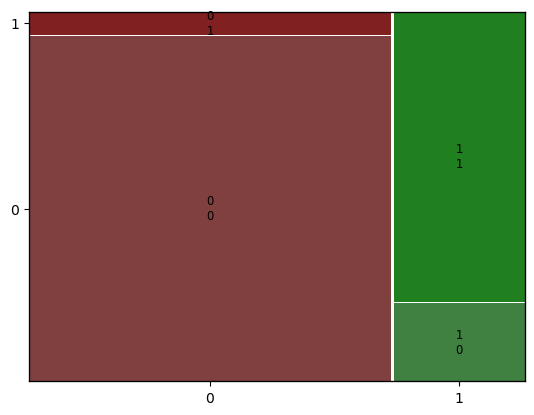

In [3265]:

mosaic(conf_matrix_1)
#Calculating Accuracy

TN1 = conf_matrix_1[0,0]
TP1 = conf_matrix_1[1,1]
FN1 = conf_matrix_1[1,0]
FP1 = conf_matrix_1[0,1]

In [3266]:
#Calculating Accuracy for model1

acc1 = (TN1 + TP1) / (TN1 + TP1 + FN1 + FP1)
print(acc)

0.8957


In [3445]:
#Summary of initial model


print(model1.summary())

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9980
Method:                           MLE   Df Model:                           19
Date:                Thu, 29 Jan 2026   Pseudo R-squ.:                  0.5930
Time:                        17:30:39   Log-Likelihood:                -2353.3
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -7.0768      0.286    -24.771      0.000      -7.637      -6.517
Marital_Married[T.True]           0.0730      0.117      0.624      0.533 

In [3449]:
print(np.exp(0.0145))

print(np.exp(-0.4527))

1.0146056349513985
0.6359088776766791


In [3268]:
#Printing AIC, Lower is better!

print(model1.aic)
print(model1.bic)

4746.6125282146495
4890.819335654173


Check AIC and BIC, make sure it goes lower for every interpretation

Log-likelihood: Measures how well the data fits. Higher = Better

Pseudo R-squared: higher  = better   . measures model vs null (intercept only)

LLR - P-value  =  lower better, just like P value, beat confidence interval


Checking p values:
variable with highest p value elected for removal: Outage_sec_perweek






In [3270]:
#Model 2, removing Outage_sec_perweek

#Creating initial logistic regression model


model2= logit("Churn ~ Population + Children + Age + Yearly_equip_failure + Techie + Multiple + Tenure + MonthlyCharge"
              "+ Bandwidth_GB_Year + Income + Marital_Married + Marital_Never_Married + Marital_Separated + Marital_Widowed + Area_Suburban"
              "+ Area_Urban + Contract_One_year + Contract_Two_Year" ,data=df_model).fit()



              

Optimization terminated successfully.
         Current function value: 0.235331
         Iterations 9


In [3271]:
#Printing AIC, Lower is better!

print(model1.aic)
print(model1.bic)

print(model2.aic)
print(model2.bic)

4746.6125282146495
4890.819335654173
4744.614807333974
4881.611274401521


Slight reduction in aic and bic, indication of improvement of model

Check for loglikelihood increase and pseudo r squared increase while LLR p value stays down for imrpoved model




In [3273]:
print(model2.summary())

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9981
Method:                           MLE   Df Model:                           18
Date:                Thu, 29 Jan 2026   Pseudo R-squ.:                  0.5930
Time:                        17:21:55   Log-Likelihood:                -2353.3
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -7.0828      0.257    -27.539      0.000      -7.587      -6.579
Marital_Married[T.True]           0.0730      0.117      0.624      0.533 

No changes in Pseudo-Rsquared and Log-likelihood and LLR p-value, continue to reduce variables. Outage_sec_perweek coef is not large in order to change the log-likelihood/pseudo r-squared.

continue to remove variables starting with the variable with the highest p value above 0.05.

Remove Population.



In [3275]:
#Model 3, reduce logit model by removing Popuation
#Refit Logit model


model3= logit("Churn ~ Children + Age + Yearly_equip_failure + Techie + Multiple + Tenure + MonthlyCharge"
              "+ Bandwidth_GB_Year + Income + Marital_Married + Marital_Never_Married + Marital_Separated + Marital_Widowed + Area_Suburban"
              "+ Area_Urban + Contract_One_year + Contract_Two_Year" ,data=df_model).fit()






Optimization terminated successfully.
         Current function value: 0.235333
         Iterations 9


In [3276]:
print(model2.aic)
print(model2.bic)


print('model3:', model3.aic , model3.bic)

4744.614807333974
4881.611274401521
model3: 4742.664435114359 4872.45056180993


Reducement in AIC and BIC, model is improved with the removal of variable "Population"



In [3279]:
print(model3.summary())

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9982
Method:                           MLE   Df Model:                           17
Date:                Thu, 29 Jan 2026   Pseudo R-squ.:                  0.5930
Time:                        17:21:55   Log-Likelihood:                -2353.3
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -7.0887      0.256    -27.704      0.000      -7.590      -6.587
Marital_Married[T.True]           0.0729      0.117      0.623      0.533 

Pseudo R-squared, Log-Likelihood and LLR p-value has not differ in Model 3 from Model 2.
Continue to remove variable with high p value above 0.05

Remove all of Area variables since it's one hot encoded. 





In [3281]:
#Model 4, reduce logit model by removing Area variables
#Refit Logit model


model4= logit("Churn ~ Children + Age + Yearly_equip_failure + Techie + Multiple + Tenure + MonthlyCharge"
              "+ Bandwidth_GB_Year + Income + Marital_Married + Marital_Never_Married + Marital_Separated + Marital_Widowed "
              "+ Contract_One_year + Contract_Two_Year" ,data=df_model).fit()






Optimization terminated successfully.
         Current function value: 0.235357
         Iterations 9


In [3282]:
print(model3.aic)
print(model3.bic)


print('model4:', model4.aic , model4.bic)

4742.664435114359
4872.45056180993
model4: 4739.141245527684 4854.506691479303


Models differ in AIC and BIC is observed, with improvements to model4.

In [3284]:
print(model4.summary())

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9984
Method:                           MLE   Df Model:                           15
Date:                Thu, 29 Jan 2026   Pseudo R-squ.:                  0.5930
Time:                        17:21:55   Log-Likelihood:                -2353.6
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -7.0901      0.251    -28.240      0.000      -7.582      -6.598
Marital_Married[T.True]           0.0739      0.117      0.632      0.528 

Log-likelihood has increased by .3 which shows improvement of the model as we want Pseudo R-squared and Log-likelihood to increase while P value to stay as close to 0 as possible


other factors has not changed. 

Removing area did not harm fit

Next model Remove: Marital variables


In [3286]:
#Model 5, reduce logit model by removing Marital variables
#Refit Logit model


model5= logit("Churn ~ Children + Age + Yearly_equip_failure + Techie + Multiple + Tenure + MonthlyCharge"
              "+ Bandwidth_GB_Year + Income + Contract_One_year + Contract_Two_Year " ,data=df_model).fit()






Optimization terminated successfully.
         Current function value: 0.235853
         Iterations 9


In [3287]:
print(model4.aic)
print(model4.bic)


print('model5:', model5.aic , model5.bic)

4739.141245527684
4854.506691479303
model5: 4741.057542223398 4827.5816266871125


AIC increased a bit but BIC decreased heavily. Good tradeoff

In [3289]:
print(model5.summary())

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9988
Method:                           MLE   Df Model:                           11
Date:                Thu, 29 Jan 2026   Pseudo R-squ.:                  0.5921
Time:                        17:21:56   Log-Likelihood:                -2358.5
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -6.9729      0.238    -29.258      0.000      -7.440      -6.506
Contract_One_year[T.True]    -3.1516      0.119    -26.487      0.000      -3.385     

Removing marital decreased explanation power but overall the model is still significant due to the high r-squared and p value, some of marital categories explain much more than the other with stronger coefficients but can only be removed as whole since the marital variables rely on each other. 

Continuing to remove variables
Yearly_equip_failure

In [3291]:
#Model 6, reduce logit model by removing Yearly_equip_failure
#Refit Logit model


model6= logit("Churn ~ Children + Age + Techie + Multiple + Tenure + MonthlyCharge"
              "+ Bandwidth_GB_Year + Income + Contract_One_year + Contract_Two_Year " ,data=df_model).fit()






Optimization terminated successfully.
         Current function value: 0.235859
         Iterations 9


In [3292]:
print(model5.aic)
print(model5.bic)


print('model6:', model6.aic , model6.bic)

4741.057542223398
4827.5816266871125
model6: 4739.178179782364 4818.491923874102


In [3293]:
print(model6.summary())

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9989
Method:                           MLE   Df Model:                           10
Date:                Thu, 29 Jan 2026   Pseudo R-squ.:                  0.5921
Time:                        17:21:56   Log-Likelihood:                -2358.6
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -6.9800      0.237    -29.391      0.000      -7.446      -6.515
Contract_One_year[T.True]    -3.1516      0.119    -26.488      0.000      -3.385     

log likelihood went up by .1 = improve explanation power

Candidate for next variable removal: Income 

In [3295]:
#Model 7, reduce logit model by removing Income
#Refit Logit model


model7= logit("Churn ~ Children + Age + Techie + Multiple + Tenure + MonthlyCharge"
              "+ Bandwidth_GB_Year + Contract_One_year + Contract_Two_Year " ,data=df_model).fit()






Optimization terminated successfully.
         Current function value: 0.235868
         Iterations 9


In [3296]:
print(model6.aic)
print(model6.bic)


print('model6:', model7.aic , model7.bic)

4739.178179782364
4818.491923874102
model6: 4737.365679736318 4809.46908345608


AIC and BIC reduced in model7 = improvement in model


In [3298]:
print(model7.summary())

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9990
Method:                           MLE   Df Model:                            9
Date:                Thu, 29 Jan 2026   Pseudo R-squ.:                  0.5921
Time:                        17:21:56   Log-Likelihood:                -2358.7
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -6.9566      0.231    -30.101      0.000      -7.410      -6.504
Contract_One_year[T.True]    -3.1512      0.119    -26.486      0.000      -3.384     

Slight increase in AIC. model improved
Last variable to remove: Multiple




In [3300]:
#Model 8, reduce logit model by removing Multiple
#Refit Logit model


model8= logit("Churn ~ Children + Age + Techie + Tenure + MonthlyCharge"
              "+ Bandwidth_GB_Year + Contract_One_year + Contract_Two_Year " ,data=df_model).fit()






Optimization terminated successfully.
         Current function value: 0.235934
         Iterations 9


In [3301]:
print(model8.aic)
print(model8.bic)
print(model7.aic)
print(model7.bic)

4736.687050462887
4801.580113810673
4737.365679736318
4809.46908345608


In [3302]:
print(model8.summary())

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9991
Method:                           MLE   Df Model:                            8
Date:                Thu, 29 Jan 2026   Pseudo R-squ.:                  0.5920
Time:                        17:21:56   Log-Likelihood:                -2359.3
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -6.9712      0.231    -30.209      0.000      -7.423      -6.519
Contract_One_year[T.True]    -3.1484      0.119    -26.470      0.000      -3.382     

In [3303]:
print(np.exp(6.9712))

print(np.exp(.1137))
      
print((np.exp(.1137) -1 )*100)

print(np.exp(-3.1484))
print((np.exp(-3.1484) - 1) * 100)


1065.500584385705
1.1204159496754904
12.041594967549042
0.04292074515001525
-95.70792548499848


Model has decreased in BIC and AIC

Model does increase in Log-likelihood with the removal of Multiple, slightly increasing explanation power.


In [3305]:
print(model8.aic)
print(model8.bic)

4736.687050462887
4801.580113810673


E2.  Provide the output and all calculations of the analysis you performed, including the following elements for your reduced logistic regression model:
•  confusion matrix
•  accuracy calculation



In [3307]:
#Creating confusion matrix
conf_matrix = model8.pred_table()


In [3308]:
print(conf_matrix)

[[6881.  469.]
 [ 574. 2076.]]


Okay so turns out there is a function just to do all of that without setting up the whole thing
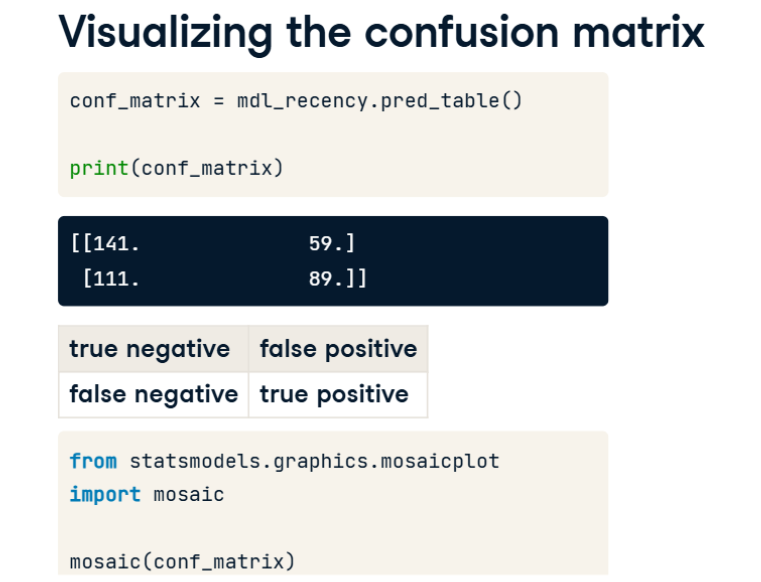

(<Figure size 640x480 with 3 Axes>,
 {('0', '0'): (0.0, 0.0, 0.7313432835820897, 0.9330802088277171),
  ('0', '1'): (0.0,
   0.9364024679639297,
   0.7313432835820897,
   0.06359753203607019),
  ('1', '0'): (0.7363184079601991,
   0.0,
   0.263681592039801,
   0.21588415971917504),
  ('1', '1'): (0.7363184079601991,
   0.21920641885538766,
   0.263681592039801,
   0.7807935811446122)})

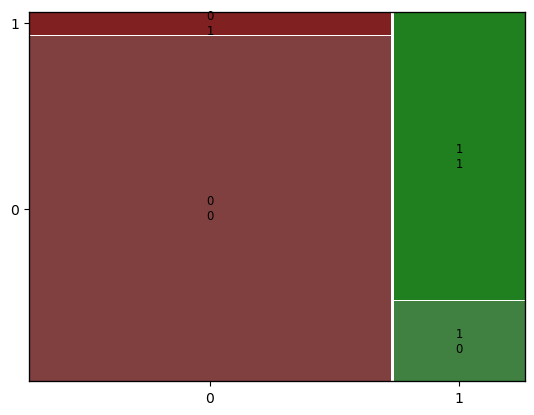

In [3310]:
mosaic(conf_matrix)

so top left and bottom right is where we guessed right, 
top right is where we guessed no but it was yes
bottom left is where we guessed yes but it was no


In [3312]:
#Calculating Accuracy

TN = conf_matrix[0,0]
TP = conf_matrix[1,1]
FN = conf_matrix[1,0]
FP = conf_matrix[0,1]

In [3313]:
acc = (TN + TP) / (TN + TP + FN + FP)
print(acc)

0.8957
